In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import os
import torch.nn as nn
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
class Cifar10Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        :param root_dir: 包含所有图片的目录路径
        :param transform: 对图片进行的预处理操作
        """
        self.root_dir = root_dir
        self.transform = transform
        # 获取该目录下所有的 jpg 图片路径
        # self.image_paths = glob.glob(os.path.join(root_dir, "*.jpg"))
        # print(len(self.image_paths))
        folder_paths = [
            name
            for name in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, name))
        ]
        folder_paths.sort()
        self.image_list = []
        self.label_list = []
        count = 0
        for folder in folder_paths:
            folder_path = root_dir + "/" + folder
            # print(folder)
            data_=glob.glob(os.path.join(folder_path, "*.png"))
            self.image_list.extend(data_)
            self.label_list.extend([count]* len(data_))
            count+=1

    def __len__(self):
        # 返回数据集的总大小
        return len(self.image_list)

    def __getitem__(self, idx):
        # 1. 根据索引获取图片路径
        img_path = self.image_list[idx]

        # 2. 读取图片并确保是RGB格式
        image = Image.open(img_path).convert("RGB")
        label = self.label_list[idx]

        # 4. 应用转换 (例如转为 Tensor, 改变大小等)
        if self.transform:
            image = self.transform(image)

        return image, label



In [3]:
from torch.utils.data import Subset

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616],
        ),
        transforms.RandomErasing(p=0.20),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616],
        ),
    ]
)

test_path = "../../../../dataset/cifar10/test"
test_dataset = Cifar10Dataset(root_dir=test_path, transform=test_transform)
train_path = "../../../../dataset/cifar10/train"
train_dataset = Cifar10Dataset(root_dir=train_path, transform=train_transform)


batch_size = 256
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False
)


class Cifar10(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(32),
        )

        self.layer1_mapping = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1, stride=2, padding=0, bias=False),
            nn.BatchNorm2d(64),
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(
                in_channels=32, out_channels=64, padding=1, kernel_size=3, bias=False, stride=2
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
        )

        self.layer2_mapping = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, stride=2, padding=0, bias=False),
            nn.BatchNorm2d(128),
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(
                in_channels=64, out_channels=128, padding=1, kernel_size=3, bias=False, stride=2
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(128),
        )

        self.layer3_mapping = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=1, stride=2, padding=0, bias=False),
            nn.BatchNorm2d(256),
        )

        self.layer4 = nn.Sequential(
            nn.Conv2d(
                in_channels=128, out_channels=256, padding=1, kernel_size=3, bias=False, stride=2
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, padding=1, kernel_size=3, bias=False),
            nn.BatchNorm2d(256),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 10),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x) + self.layer1_mapping(x)
        x = self.relu(x)

        x = self.layer3(x) + self.layer2_mapping(x)
        x = self.relu(x)

        x = self.layer4(x) + self.layer3_mapping(x)
        x = self.relu(x)

        x = self.classifier(x)
        return x

In [4]:
model = Cifar10().to(device)
print(model)
num_epochs=150
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4, nesterov=True
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=4e-5)
# print(model)

Cifar10(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer1_mapping): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2):

In [5]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device).long()

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计 loss
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # 统计 accuracy
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
        # if step % 20 == 0:
        #     print(f"Step [{step}/{len(train_loader)}], Training Loss: {loss.item():.4f}")

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).long()

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [6]:


train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_test_acc = 0.0
epoch = 0

In [7]:

for _ in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    scheduler.step()
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "cifar-10.pt")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} |"
        f"LR: {current_lr:.6f}"
    )
    epoch+=1

Epoch [1/150] Train Loss: 1.7699, Train Acc: 0.3961 | Test Loss: 1.5595, Test Acc: 0.5106 |LR: 0.049995
Epoch [2/150] Train Loss: 1.4042, Train Acc: 0.5982 | Test Loss: 1.2890, Test Acc: 0.6520 |LR: 0.049978
Epoch [3/150] Train Loss: 1.2511, Train Acc: 0.6781 | Test Loss: 1.2237, Test Acc: 0.6788 |LR: 0.049951
Epoch [4/150] Train Loss: 1.1457, Train Acc: 0.7310 | Test Loss: 1.1415, Test Acc: 0.7295 |LR: 0.049912
Epoch [5/150] Train Loss: 1.0761, Train Acc: 0.7603 | Test Loss: 1.0556, Test Acc: 0.7596 |LR: 0.049863
Epoch [6/150] Train Loss: 1.0308, Train Acc: 0.7812 | Test Loss: 0.9965, Test Acc: 0.7878 |LR: 0.049803
Epoch [7/150] Train Loss: 0.9955, Train Acc: 0.7994 | Test Loss: 0.9434, Test Acc: 0.8113 |LR: 0.049732
Epoch [8/150] Train Loss: 0.9661, Train Acc: 0.8107 | Test Loss: 0.9383, Test Acc: 0.8161 |LR: 0.049650
Epoch [9/150] Train Loss: 0.9450, Train Acc: 0.8204 | Test Loss: 1.0062, Test Acc: 0.7801 |LR: 0.049558
Epoch [10/150] Train Loss: 0.9212, Train Acc: 0.8326 | Test Loss

Best test acc: 0.9405


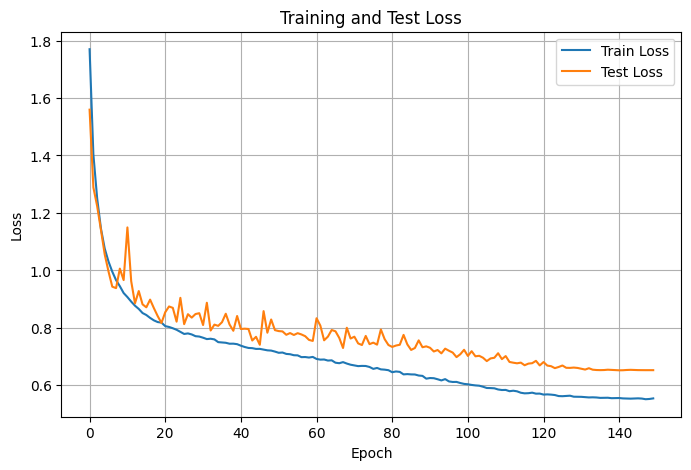

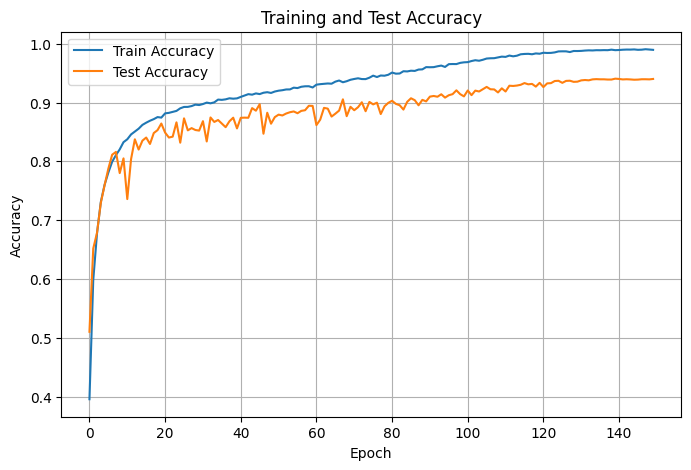

In [8]:
print(f"Best test acc: {best_test_acc:.4f}")
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()